In [1]:
import geopandas as gpd
import pandas as pd


from shapely.ops import unary_union, linemerge
from shapely.geometry import Point, LineString, MultiLineString
from shapely.geometry import mapping


import networkx as nx


import folium
from folium import Map, GeoJson


import json
import mapillary as mly




### netzwerk einlesen

In [2]:
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_major_highways_germany_250528.geojson.gz")

# use not only the major highways, but all highways for this
cycleways=gpd.read_file("../preprocessing/processed_osm_files/processed_cycleways_germany_250528.geojson.gz")


In [3]:
cycleways

,osm_id,highway,bicycle,cycleway,cycleway_left,cycleway_opposite,cycleway_right,cycleway_both,cycleway_lane,cycleway_track,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,surface,width,geometry
0,92,residential,None,None,None,None,None,None,None,None,30,None,None,None,None,Eigenheimstraße,None,asphalt,None,"LINESTRING (13.73698 51.01663, 13.73752 51.016..."
1,93,residential,None,None,None,None,None,None,None,None,30,None,None,None,None,Eigenheimberg,None,asphalt,None,"LINESTRING (13.73939 51.01669, 13.73967 51.016..."
2,99,tertiary,None,None,None,None,no,None,None,None,None,None,None,None,None,None,None,asphalt,None,"LINESTRING (11.36639 48.17411, 11.36643 48.174..."
3,103,residential,None,None,None,None,None,None,None,None,5,None,None,None,None,Altmockritz,None,None,None,"LINESTRING (13.74127 51.01615, 13.74149 51.016..."
4,104,unclassified,None,None,None,None,None,no,None,None,50,None,None,None,None,Münzmeisterstraße,None,asphalt,None,"LINESTRING (13.74142 51.02366, 13.74139 51.023..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7336294,1390548863,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38298 52.65611, 11.383 52.6558,..."
7336295,1390548864,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38251 52.65568, 11.38266 52.655..."
7336296,1390548865,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38262 52.65609, 11.38266 52.655..."
7336297,1390550366,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,grass,None,"LINESTRING (13.87816 52.08202, 13.87811 52.08226)"


In [63]:
filtered_cycleways = cycleways[
    (cycleways["bicycle"].isin(["yes", "designated"])) |
    (cycleways["highways"].isin(["cycleway"])) |
    (cycleways["cycleway"].notnull()) |
    (cycleways["cycleway_left"].notnull()) |
    (cycleways["cycleway_right"].notnull()) |
    (cycleways["cycleway_both"].notnull()) |
    (cycleways["cycleway_lane"].notnull()) |
    (cycleways["cycleway_track"].notnull()) |
    (cycleways["cycleway_opposite"].notnull()) 
]
filtered_cycleways

KeyError: 'highways'

In [ ]:
filtered_cycleways.highway.value_counts()

highway
path              430541
residential       345813
secondary         233991
track             190037
tertiary          188369
footway           177095
primary           124364
unclassified      104910
service            70855
cycleway           39145
pedestrian         13871
living_street      13013
primary_link        7240
secondary_link      6275
trunk               3914
trunk_link          3212
tertiary_link       3186
steps               2546
motorway            2298
motorway_link       1797
construction        1519
bridleway            389
proposed             133
platform             101
busway                59
elevator              31
road                  16
bus_stop              13
planned               11
corridor               9
crossing               5
no                     3
disused                2
raceway                2
yes                    1
rest_area              1
razed                  1
passing_place          1
Name: count, dtype: int64

In [64]:
# mapillary map feature data: traffic signs einlesen

In [26]:
# mapillary_trafficsigns = gpd.read_parquet("../preprocessing/mapillary_map-feature-data_berlin_2025-06-07.parquet")

#mapillary_mapfeaturepoints = gpd.read_parquet("../preprocessing/mapillary_map-feature-points_data_bremen_2025-06-11.parquet")

mapillary_mapfeaturepoints = gpd.read_parquet("../preprocessing/mapillary_map-feature-points_data_bbb_2025-06-11.parquet")


mapillary_mapfeaturepoints

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y
0,POINT (11.27341 53.11882),2021-07-03,118488700476446,2021-07-03,object--traffic-sign--front,8705,5328
1,POINT (11.27681 53.11384),2021-07-03,1283980285353032,2021-07-03,object--street-light,8705,5328
2,POINT (11.27773 53.10978),2021-07-03,398107614960247,2021-07-03,object--traffic-sign--front,8705,5328
3,POINT (11.27341 53.11882),2021-07-03,118488687143114,2021-07-03,object--traffic-sign--front,8705,5328
4,POINT (11.27292 53.11977),2021-07-03,118488703809779,2021-07-03,object--traffic-sign--front,8705,5328
...,...,...,...,...,...,...,...
2894575,POINT (14.73256 51.65574),2024-06-28,1170872657387552,2024-06-28,object--traffic-sign--front,8862,5437
2894576,POINT (14.73306 51.64995),2024-06-28,991198522456798,2024-06-28,object--traffic-sign--front,8862,5437
2894577,POINT (14.73267 51.6557),2024-06-28,1170872647387553,2024-06-28,object--traffic-sign--temporary-front,8862,5437
2894578,POINT (14.73256 51.65574),2024-06-28,1170872660720885,2024-06-28,object--traffic-sign--front,8862,5437


In [ ]:
# https://www.mapillary.com/developer/api-documentation/traffic-signs?locale=de_DE

In [ ]:
# # Tempo 30 Schilder in Germany
# mapillary_trafficsigns_237=mapillary_trafficsigns[mapillary_trafficsigns.value=="regulatory--bicycles-only--g1"]
# mapillary_trafficsigns_237

,geometry,first_seen_at,id,last_seen_at,value
165,POINT (5.90829 51.01523),2016-07-30,301371998064492,2016-07-30,regulatory--bicycles-only--g1
556,POINT (5.89001 51.0097),2019-02-16,531235461227628,2019-02-16,regulatory--bicycles-only--g1
561,POINT (5.89027 51.01019),2023-01-29,1235766320341501,2023-01-29,regulatory--bicycles-only--g1
566,POINT (5.89008 51.0098),2020-12-29,3766671783461527,2020-12-29,regulatory--bicycles-only--g1
613,POINT (5.88985 51.0099),2022-04-13,510975163980187,2022-04-13,regulatory--bicycles-only--g1
...,...,...,...,...,...
5346458,POINT (15.00467 51.15092),2016-10-17,822078018402808,2016-10-17,regulatory--bicycles-only--g1
5347051,POINT (15.00605 51.1386),2019-02-05,2778281845815815,2019-02-05,regulatory--bicycles-only--g1
5347483,POINT (15.00274 51.15037),2018-05-30,909902779585806,2018-05-30,regulatory--bicycles-only--g1
5347496,POINT (15.00273 51.15036),2018-07-09,482843769728007,2018-07-09,regulatory--bicycles-only--g1


In [27]:
# LANE MARKINGS!!!
# https://www.mapillary.com/developer/api-documentation/points?locale=de_DE
mapillary_mapfeaturepoints_bclane=mapillary_mapfeaturepoints[mapillary_mapfeaturepoints.value=="marking--discrete--symbol--bicycle"]
mapillary_mapfeaturepoints_bclane

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y
4587,POINT (11.75902 52.99078),2019-04-07,462129715047467,2019-04-07,marking--discrete--symbol--bicycle,8727,5337
4772,POINT (11.76137 52.98581),2024-04-29,371164558607059,2024-04-29,marking--discrete--symbol--bicycle,8727,5338
5704,POINT (11.86058 53.081),2018-10-31,151444900330513,2018-10-31,marking--discrete--symbol--bicycle,8731,5330
5851,POINT (11.86073 53.08098),2024-11-23,1081252720154283,2024-11-23,marking--discrete--symbol--bicycle,8731,5330
17438,POINT (12.25012 52.97848),2024-11-30,366383106533617,2024-11-30,marking--discrete--symbol--bicycle,8749,5338
...,...,...,...,...,...,...,...
2889196,POINT (14.64843 51.74598),2020-09-13,476395140131298,2020-09-13,marking--discrete--symbol--bicycle,8858,5430
2889353,POINT (14.64879 51.74732),2020-09-13,5961560383886611,2020-09-13,marking--discrete--symbol--bicycle,8858,5430
2889801,POINT (14.6484 51.74623),2020-09-13,1309414479452426,2020-09-13,marking--discrete--symbol--bicycle,8858,5430
2889833,POINT (14.63998 51.74525),2020-09-13,501553947788791,2020-09-13,marking--discrete--symbol--bicycle,8858,5430


In [ ]:
### todo need https://www.mapillary.com/app/?lat=52.559854630924434&lng=13.413265420137122&z=18.23446593125048&focus=map&dateFrom=2023-06-01&pKey=314063294712479&x=0.5051267031266303&y=0.5410275929812571&zoom=0&mapFeature%5B%5D=marking--discrete--symbol--bicycle
## LANE MARKINGS!!!

In [ ]:
# mapillary_trafficsigns_t30_recent = mapillary_trafficsigns_t30[mapillary_trafficsigns_t30["last_seen_at"] > "2024-01-01"]


In [ ]:
# from datetime import datetime

# def months_between(date1, date2):
#     d1 = datetime.strptime(date1, "%Y-%m-%d")
#     d2 = datetime.strptime(date2, "%Y-%m-%d")
#     return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

# mapillary_trafficsigns_t30_recent_6months = mapillary_trafficsigns_t30_recent[
#     mapillary_trafficsigns_t30_recent.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 6, axis=1)
# ]

<Axes: >

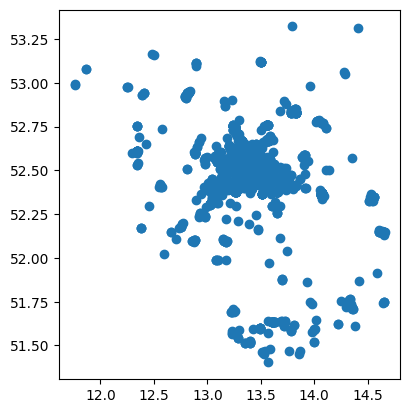

In [28]:
mapillary_mapfeaturepoints_bclane.plot()

In [29]:
# mapillary_mapfeaturepoints_bclane.explore(
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at"]
# )

In [ ]:
df_buffered = mapillary_mapfeaturepoints_bclane.to_crs(25833).copy()
df_buffered["geometry"] = df_buffered.geometry.buffer(50)
df_buffered = df_buffered.to_crs(mapillary_mapfeaturepoints_bclane.crs)
df_buffered

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y
4587,"POLYGON ((11.75977 52.99081, 11.75977 52.99076...",2019-04-07,462129715047467,2019-04-07,marking--discrete--symbol--bicycle,8727,5337
4772,"POLYGON ((11.76212 52.98583, 11.76212 52.98579...",2024-04-29,371164558607059,2024-04-29,marking--discrete--symbol--bicycle,8727,5338
5704,"POLYGON ((11.86133 53.08102, 11.86133 53.08097...",2018-10-31,151444900330513,2018-10-31,marking--discrete--symbol--bicycle,8731,5330
5851,"POLYGON ((11.86148 53.081, 11.86148 53.08095, ...",2024-11-23,1081252720154283,2024-11-23,marking--discrete--symbol--bicycle,8731,5330
17438,"POLYGON ((12.25086 52.9785, 12.25086 52.97845,...",2024-11-30,366383106533617,2024-11-30,marking--discrete--symbol--bicycle,8749,5338
...,...,...,...,...,...,...,...
2889196,"POLYGON ((14.64916 51.74598, 14.64915 51.74594...",2020-09-13,476395140131298,2020-09-13,marking--discrete--symbol--bicycle,8858,5430
2889353,"POLYGON ((14.64952 51.74732, 14.64951 51.74728...",2020-09-13,5961560383886611,2020-09-13,marking--discrete--symbol--bicycle,8858,5430
2889801,"POLYGON ((14.64913 51.74624, 14.64912 51.74619...",2020-09-13,1309414479452426,2020-09-13,marking--discrete--symbol--bicycle,8858,5430
2889833,"POLYGON ((14.6407 51.74525, 14.6407 51.7452, 1...",2020-09-13,501553947788791,2020-09-13,marking--discrete--symbol--bicycle,8858,5430


In [88]:
df_buffered=df_buffered[df_buffered["last_seen_at"] > "2020-01-01"]

In [40]:
#df_6months_30_buffered.plot()

In [41]:
# # Spatial join: find highways_in_bl segments that intersect with buffered 30-signs
# intersected = gpd.sjoin(highways_in_bl, df_6months_30_buffered, how="inner", predicate="intersects")

# # Check if intersected highways have maxspeed == "30"
# intersected_30 = intersected[intersected["maxspeed"] == "30"]

# intersected_30

In [42]:
# # Prüfe, ob ein highways_in_bl Segment mit maxspeed==30 oder maxspeed_conditional==30 ein df_6months_30_buffered-Polygon schneidet
# def has_30_intersection(row, highways_gdf):
#     # highways_gdf: nur maxspeed==30 oder maxspeed_conditional==30
#     return highways_gdf.intersects(row.geometry).any()

# # Filter für relevante Straßen
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ]

# # Neue Spalte: True, falls mind. ein Segment schneidet
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.apply(
#     lambda row: has_30_intersection(row, highways_30), axis=1
# )

# df_6months_30_buffered

In [89]:
from geopandas import sjoin

# # Step 1: Filter highways to only those with maxspeed 30
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ].copy()

# Step 2: Ensure CRS matches
df_buffered = df_buffered.to_crs(filtered_cycleways.crs)

# Step 3: Perform spatial join (find intersecting geometries)
joined = sjoin(df_buffered, filtered_cycleways, how="inner", predicate="intersects")

# # Step 4: Mark which polygons had at least one intersection
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.index.isin(joined.index)

# Zeilen, die mindestens einen Match haben
matches = joined.index.unique()

# Standardmäßig alles auf False setzen
df_buffered["has_cw_intersection"] = False

# Nur die gematchten Indizes auf True setzen
df_buffered.loc[matches, "has_cw_intersection"] = True



In [70]:
#df_buffered.id.unique()

In [90]:
df_buffered.has_cw_intersection.value_counts()

has_cw_intersection
True     11810
False       85
Name: count, dtype: int64

In [91]:
# import matplotlib.colors as mcolors

# cmap = mcolors.ListedColormap(["red", "green"])
# df_buffered.explore(
#     column="has_cw_intersection",
#     cmap=cmap,
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
# )

In [92]:
df_buffered_false=df_buffered[df_buffered.has_cw_intersection== False]

In [93]:
df_buffered_false.explore(
    color="red",
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
)

In [94]:
df_buffered_false


,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,has_cw_intersection
75648,"POLYGON ((12.54791 52.40789, 12.54791 52.40784...",2021-06-27,1410473699353083,2021-06-27,marking--discrete--symbol--bicycle,8763,5381,False
84686,"POLYGON ((12.59032 52.0204, 12.59032 52.02036,...",2024-10-21,429466123520501,2024-10-21,marking--discrete--symbol--bicycle,8764,5410,False
106951,"POLYGON ((12.7084 52.10681, 12.7084 52.10677, ...",2024-10-21,1263695987988961,2024-10-21,marking--discrete--symbol--bicycle,8770,5403,False
155955,"POLYGON ((12.89153 53.11467, 12.89153 53.11462...",2024-06-15,896495728951279,2024-06-15,marking--discrete--symbol--bicycle,8778,5328,False
156111,"POLYGON ((12.89149 53.11484, 12.89148 53.11479...",2024-06-15,896495725617946,2024-06-15,marking--discrete--symbol--bicycle,8778,5328,False
...,...,...,...,...,...,...,...,...
2817700,"POLYGON ((14.34994 52.57059, 14.34994 52.57055...",2020-12-06,512959353392656,2020-12-06,marking--discrete--symbol--bicycle,8845,5369,False
2827707,"POLYGON ((14.37922 51.61014, 14.37922 51.61009...",2024-03-11,1550161045748778,2024-03-11,marking--discrete--symbol--bicycle,8846,5440,False
2828966,"POLYGON ((14.41232 53.31427, 14.41232 53.31423...",2020-02-14,298937421711981,2020-02-14,marking--discrete--symbol--bicycle,8847,5313,False
2848430,"POLYGON ((14.5218 52.35024, 14.5218 52.3502, 1...",2025-03-23,480768901782935,2025-03-23,marking--discrete--symbol--bicycle,8852,5385,False


In [95]:
## retrieve the image ID for the map features

In [96]:
import sys
import os
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout


In [97]:
### this takes 0.5s per image ID, TODO: would be nice to have tqdm at some point so see the progress

from tqdm import tqdm
tqdm.pandas()  # aktiviert tqdm für .progress_apply()

# Load the token from JSON config file
with open("../preprocessing/config_mapillary_privat.json", "r") as f:
    config = json.load(f)

# Set the token
access_token = config["ACCESS_TOKEN"]
mly.interface.set_access_token(access_token)



def get_image_id(map_feature_id):
    feature_str = mly.interface.feature_from_key(key=str(map_feature_id))
    feature = json.loads(feature_str)
    images = feature["features"]["properties"]["images"]["data"]
    return images[-1]["id"] if images else None


import logging

# Setze alle aktiven Logger auf WARNING oder ERROR
for name in logging.root.manager.loggerDict:
    logging.getLogger(name).setLevel(logging.WARNING)

# Optional: Basis-Logging-Level generell auf ERROR setzen
logging.basicConfig(level=logging.ERROR)

with suppress_stdout():
    df_buffered_false["image_id"] = df_buffered_false["id"].progress_apply(get_image_id)


100%|██████████| 85/85 [01:48<00:00,  1.27s/it]
/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [98]:
df_buffered_false

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,has_cw_intersection,image_id
75648,"POLYGON ((12.54791 52.40789, 12.54791 52.40784...",2021-06-27,1410473699353083,2021-06-27,marking--discrete--symbol--bicycle,8763,5381,False,204037568275038
84686,"POLYGON ((12.59032 52.0204, 12.59032 52.02036,...",2024-10-21,429466123520501,2024-10-21,marking--discrete--symbol--bicycle,8764,5410,False,1246902099893020
106951,"POLYGON ((12.7084 52.10681, 12.7084 52.10677, ...",2024-10-21,1263695987988961,2024-10-21,marking--discrete--symbol--bicycle,8770,5403,False,1100001751718004
155955,"POLYGON ((12.89153 53.11467, 12.89153 53.11462...",2024-06-15,896495728951279,2024-06-15,marking--discrete--symbol--bicycle,8778,5328,False,926953799234021
156111,"POLYGON ((12.89149 53.11484, 12.89148 53.11479...",2024-06-15,896495725617946,2024-06-15,marking--discrete--symbol--bicycle,8778,5328,False,393480780371044
...,...,...,...,...,...,...,...,...,...
2817700,"POLYGON ((14.34994 52.57059, 14.34994 52.57055...",2020-12-06,512959353392656,2020-12-06,marking--discrete--symbol--bicycle,8845,5369,False,999923273876141
2827707,"POLYGON ((14.37922 51.61014, 14.37922 51.61009...",2024-03-11,1550161045748778,2024-03-11,marking--discrete--symbol--bicycle,8846,5440,False,437545085508392
2828966,"POLYGON ((14.41232 53.31427, 14.41232 53.31423...",2020-02-14,298937421711981,2020-02-14,marking--discrete--symbol--bicycle,8847,5313,False,162957792434735
2848430,"POLYGON ((14.5218 52.35024, 14.5218 52.3502, 1...",2025-03-23,480768901782935,2025-03-23,marking--discrete--symbol--bicycle,8852,5385,False,870886861830026


In [99]:
sc7_poly=df_buffered_false.copy()


In [100]:
sc7_poly.to_file("scenario7_missing-cw_polys.fgb", driver="FlatGeobuf")

In [101]:
sc7_centroids = sc7_poly.copy()
sc7_centroids=sc7_centroids.to_crs(25832)
sc7_centroids["geometry"] = sc7_centroids.geometry.centroid
sc7_centroids=sc7_centroids.to_crs(4326)

sc7_centroids

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,has_cw_intersection,image_id
75648,POINT (12.54718 52.40787),2021-06-27,1410473699353083,2021-06-27,marking--discrete--symbol--bicycle,8763,5381,False,204037568275038
84686,POINT (12.58959 52.02039),2024-10-21,429466123520501,2024-10-21,marking--discrete--symbol--bicycle,8764,5410,False,1246902099893020
106951,POINT (12.70767 52.1068),2024-10-21,1263695987988961,2024-10-21,marking--discrete--symbol--bicycle,8770,5403,False,1100001751718004
155955,POINT (12.89078 53.11466),2024-06-15,896495728951279,2024-06-15,marking--discrete--symbol--bicycle,8778,5328,False,926953799234021
156111,POINT (12.89074 53.11482),2024-06-15,896495725617946,2024-06-15,marking--discrete--symbol--bicycle,8778,5328,False,393480780371044
...,...,...,...,...,...,...,...,...,...
2817700,POINT (14.3492 52.57059),2020-12-06,512959353392656,2020-12-06,marking--discrete--symbol--bicycle,8845,5369,False,999923273876141
2827707,POINT (14.3785 51.61013),2024-03-11,1550161045748778,2024-03-11,marking--discrete--symbol--bicycle,8846,5440,False,437545085508392
2828966,POINT (14.41157 53.31427),2020-02-14,298937421711981,2020-02-14,marking--discrete--symbol--bicycle,8847,5313,False,162957792434735
2848430,POINT (14.52107 52.35024),2025-03-23,480768901782935,2025-03-23,marking--discrete--symbol--bicycle,8852,5385,False,870886861830026


In [102]:
sc7_centroids.to_file("scenario7_missing-cw_points.fgb", driver="FlatGeobuf")

In [103]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [104]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario7_missing-cw_points.fgb",
    polys_fgb="scenario7_missing-cw_polys.fgb",
    output_pmtiles="scenario7_missing-cw_bbb.pmtiles",
    layer_name="scenario7"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
85 features, 4522 bytes of geometry and attributes, 6542 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8806/5372  
detected indexed FlatGeobuf: assigning feature IDs by sequence
85 features, 20976 bytes of geometry and attributes, 6542 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17661/10706  


✅ Combined PMTiles created
